In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
dataset_url="https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir=tf.keras.utils.get_file('flower_photos',origin=dataset_url,cache_dir='.',untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [3]:
data_dir

'./datasets/flower_photos'

In [4]:
import pathlib
# The original dataset is extracted to './datasets/flower_photos',
# and the tarball itself contains a top-level 'flower_photos' directory.
# So the actual images are in './datasets/flower_photos/flower_photos'.
data_dir = pathlib.Path('datasets/flower_photos') / 'flower_photos'
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [5]:
image_count=len(list(data_dir.glob('*/*.jpg')))

In [6]:
image_count

3670

In [7]:
import os
print(os.listdir(data_dir))

['sunflowers', 'tulips', 'LICENSE.txt', 'roses', 'dandelion', 'daisy']


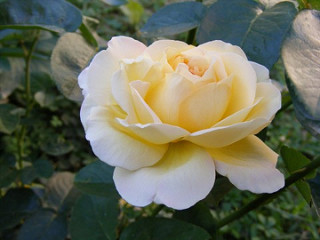

In [8]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[3]))

In [9]:
flowers_images_dict={
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'tulips': list(data_dir.glob('tulips/*')),

}

In [10]:
flowers_images_dict['roses']

[PosixPath('datasets/flower_photos/flower_photos/roses/7316409504_7cf3707f8a_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4093390305_4010c736c9.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/12045735155_42547ce4e9_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4900231976_f8ced2b42a_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/7551637034_55ae047756_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15190665092_5c1c37a066_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2609353769_dc3654f12f.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16643944275_3cd4cd966c.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/459042023_6273adc312_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/18584002386_cec0df537d_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/272481307_1eb47ba3e0_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/247

In [11]:
flowers_labels_dict={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4
}

In [12]:
flowers_images_dict['roses'][0]

PosixPath('datasets/flower_photos/flower_photos/roses/7316409504_7cf3707f8a_m.jpg')

In [13]:
img=cv2.imread(flowers_images_dict['roses'][0])

In [14]:
img.shape

(240, 180, 3)

In [15]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [16]:
X,Y=[],[]
for flower_name,images in flowers_images_dict.items():
  for image in images:
    img=cv2.imread(image)
    resized=cv2.resize(img,(180,180))
    X.append(resized)
    Y.append(flowers_labels_dict[flower_name])




array([[[139, 140, 132],
        [ 40, 162,  83],
        [ 12,  85,  51],
        ...,
        [  0,   0,   1],
        [  4,  10,   9],
        [  0,   5,   4]],

       [[ 65, 139,  95],
        [ 22,  64,  55],
        [ 85, 117, 102],
        ...,
        [  1,   0,   0],
        [  4,   5,   5],
        [  0,   3,   2]],

       [[ 13,  64,  18],
        [ 26,  80,  66],
        [ 23, 134,  69],
        ...,
        [  0,   1,   0],
        [  8,  12,  11],
        [  4,   9,   9]],

       ...,

       [[ 36, 143, 181],
        [ 34,  59, 140],
        [ 75, 148, 200],
        ...,
        [  5, 104,  39],
        [ 22,  91,  55],
        [ 18,  37,  64]],

       [[ 48, 113, 155],
        [ 78, 141, 179],
        [ 50,  78, 140],
        ...,
        [ 23, 106,  54],
        [ 26, 108,  56],
        [  0,  75,  28]],

       [[ 44,  87, 151],
        [ 81, 121, 165],
        [ 38,  84, 131],
        ...,
        [ 30, 102,  46],
        [ 39, 114,  57],
        [ 14,  99,  48]]], dtype=uint8)
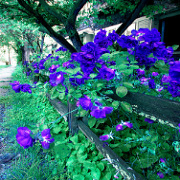

In [17]:
X[0]

In [18]:
Y[0]

0

In [19]:
X=np.array(X)
Y=np.array(Y)

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [22]:
X_train.shape

(2936, 180, 180, 3)

In [23]:
X_test.shape

(734, 180, 180, 3)

In [24]:
X_train=X_train/255
X_test=X_test/255

In [25]:
len(flowers_labels_dict)

5

In [26]:
num_classes = len(flowers_labels_dict)

model=Sequential([
    layers.Conv2D(16,3,padding='same',activation='relu',input_shape=(180,180,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(num_classes,activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train,Y_train,epochs=50)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.4489 - loss: 1.2739
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6294 - loss: 0.9718
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7309 - loss: 0.7369
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8222 - loss: 0.5188
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8948 - loss: 0.3012
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9465 - loss: 0.1653
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9799 - loss: 0.0792
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9799 - loss: 0.0755
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9908 - loss: 0.0352
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9898 - loss: 0.0513
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9918 - loss: 0.0315
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy

In [27]:
model.evaluate(X_test,Y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6512 - loss: 3.8170


[3.816957473754883, 0.6512261629104614]

In [28]:
Y_pred=model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


In [36]:
np.argmax(Y_pred[0])

np.int64(4)

In [37]:
Y_test[0]

np.int64(3)

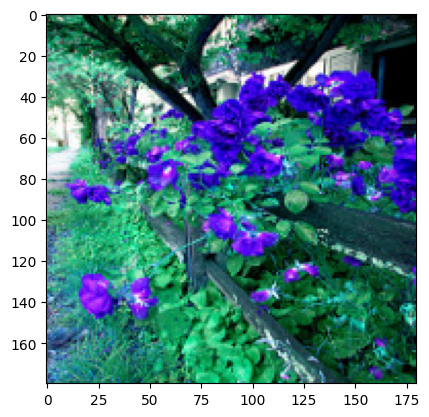

In [38]:
plt.imshow(X[0])

In [54]:
data_augmentation=keras.Sequential([
    layers.RandomFlip("horizontal",
                      input_shape=(180,180,3)),
    layers.RandomContrast(0.1),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


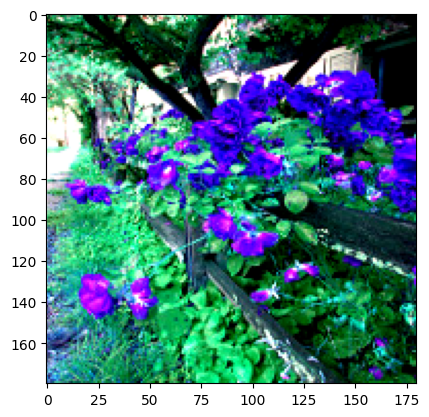

In [51]:
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

In [60]:
num_classes = len(flowers_labels_dict)
model = Sequential([

    data_augmentation,

    layers.Conv2D(16,3,padding='same',activation='relu',
                  input_shape=(180,180,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(num_classes,activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    epochs=20
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.4089 - loss: 1.3664 - val_accuracy: 0.5102 - val_loss: 1.0826
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5362 - loss: 1.1322 - val_accuracy: 0.6378 - val_loss: 0.9043
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5758 - loss: 1.0379 - val_accuracy: 0.7075 - val_loss: 0.8056
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6359 - loss: 0.9588 - val_accuracy: 0.6310 - val_loss: 0.8752
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6716 - loss: 0.8589 - val_accuracy: 0.7483 - val_loss: 0.7339
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6870 - loss: 0.8177 - val_accuracy: 0.7075 - val_loss: 0.7270
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7117 - loss: 0.7598 - val_accuracy: 0.7211 - val_loss: 0.7354
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7372 - loss: 0.7097 - val_accuracy: 0.6956 - v

In [61]:
model.evaluate(X_test,Y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7398 - loss: 0.9126


[0.9125940203666687, 0.7397820353507996]

In [63]:
Y_pred=model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [64]:
Y_test[:6]

array([3, 4, 4, 0, 0, 0])

In [75]:
y_pred=np.argmax(Y_pred[:6],axis=1)

In [76]:
y_pred[:6]

array([3, 4, 0, 0, 0, 0])

In [68]:
from sklearn.metrics import classification_report

In [78]:
y_pred_full = np.argmax(Y_pred, axis=1)
print(classification_report(Y_test, y_pred_full))

              precision    recall  f1-score   support

           0       0.61      0.74      0.67       136
           1       0.76      0.67      0.71       121
           2       0.84      0.78      0.81       170
           3       0.71      0.92      0.80       118
           4       0.79      0.64      0.71       189

    accuracy                           0.74       734
   macro avg       0.74      0.75      0.74       734
weighted avg       0.75      0.74      0.74       734



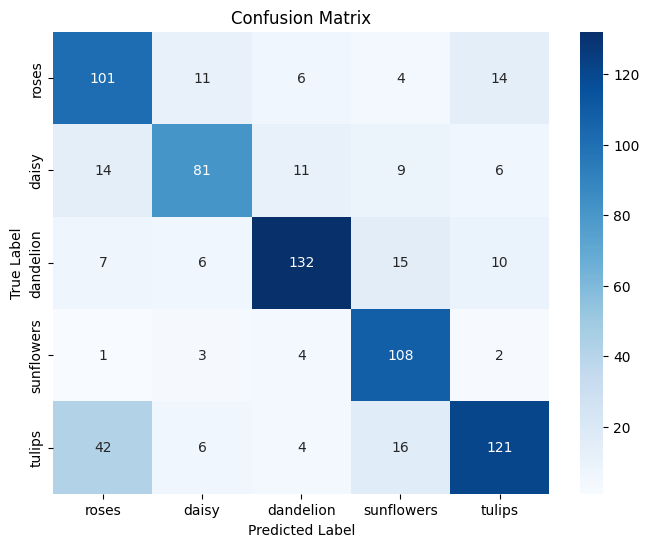

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_pred_full)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(flowers_labels_dict.keys()),
            yticklabels=list(flowers_labels_dict.keys()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()